# 10 · Nonlinear viscoelasticity

Stir a polymer solution with a rod and it climbs the rod instead of forming a vortex; start shearing it
suddenly and the stress overshoots before settling. Linear viscoelasticity (notebooks 07-09) cannot describe
this: it applies only to small deformations. **Constitutive models** such as the upper-convected Maxwell,
Giesekus and Phan-Thien-Tanner models extend the linear spectrum to large, fast deformations.

**What you will learn**
- recognise nonlinear viscoelastic effects: shear thinning, stress overshoot, normal stresses
- use differential constitutive models (UCM, Giesekus, PTT) built on a linear spectrum
- fit a nonlinear parameter and predict other flows

**Before you start:** notebooks 07-09; ordinary differential equations  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engrheo import datasets, constitutive as cm
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

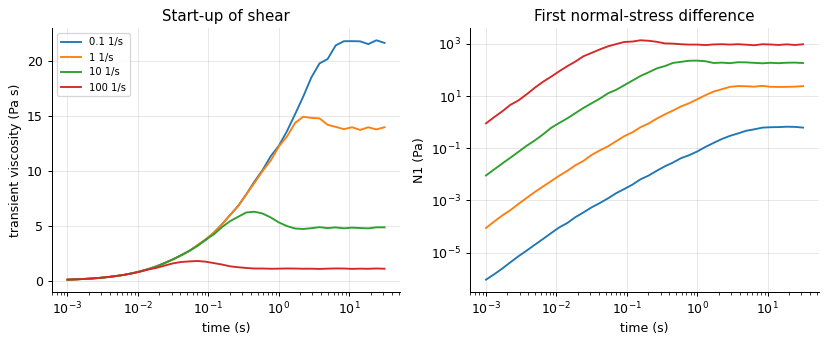

In [2]:
sol = pd.read_csv(datasets.path("polymer_solution_startup.csv"), comment="#")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
for rate, grp in sol.groupby("shear_rate_1_s"):
    a1.semilogx(grp.time_s, grp.shear_stress_Pa / rate, label=f"{rate:g} 1/s")
    a2.loglog(grp.time_s, grp.N1_Pa, label=f"{rate:g} 1/s")
a1.set(xlabel="time (s)", ylabel="transient viscosity (Pa s)", title="Start-up of shear"); a1.legend(fontsize=8)
a2.set(xlabel="time (s)", ylabel="N1 (Pa)", title="First normal-stress difference"); plt.show()

Three nonlinear effects are visible: the viscosity falls with rate (shear thinning), the stress overshoots
at high rates before reaching steady state, and a **first normal-stress difference** $N_1$ builds up. A positive
$N_1$ pulls the fluid towards the rotation axis - the rod-climbing (Weissenberg) effect - and causes die swell.

## Linear spectrum plus one nonlinear parameter
The linear spectrum (from a frequency sweep) is known: $g$ = 60, 25, 8 Pa at $\tau$ = 0.02, 0.2, 2 s. The UCM model
uses it unchanged - and predicts neither shear thinning nor overshoot. The Giesekus model adds one parameter,
the mobility $\alpha$; fit it to all start-up curves at once:

fitted Giesekus alpha = 0.251  (true 0.25); rms misfit 1.0 %


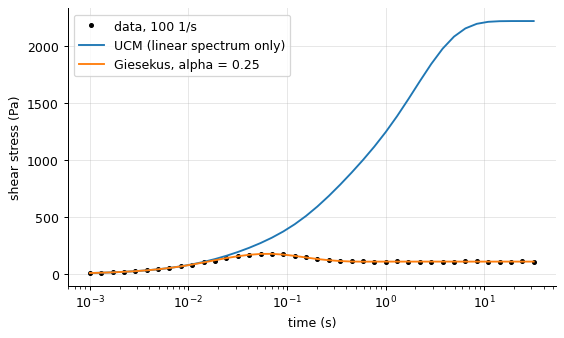

In [3]:
g, tau = np.array([60.0, 25.0, 8.0]), np.array([0.02, 0.2, 2.0])
groups = list(sol.groupby("shear_rate_1_s"))

def misfit(alpha):
    modes = cm.modes_from_spectrum(g, tau, "giesekus", alpha=alpha)
    res = []
    for rate, grp in groups:
        r = cm.startup_shear(modes, rate, np.r_[0.0, grp.time_s.to_numpy()])
        res.append(np.log(r["stress"][1:] / grp.shear_stress_Pa.to_numpy()))
    return float(np.mean(np.concatenate(res) ** 2))

alpha = optimize.minimize_scalar(misfit, bounds=(0.01, 0.5), method="bounded", options={"xatol": 1e-4}).x
print(f"fitted Giesekus alpha = {alpha:.3f}  (true 0.25); rms misfit {np.sqrt(misfit(alpha))*100:.1f} %")
ucm, gie = cm.modes_from_spectrum(g, tau), cm.modes_from_spectrum(g, tau, "giesekus", alpha=alpha)
rate, grp = groups[-1]
tt = np.r_[0.0, grp.time_s.to_numpy()]
plt.semilogx(grp.time_s, grp.shear_stress_Pa, "ko", ms=3, label=f"data, {rate:g} 1/s")
plt.semilogx(tt[1:], cm.startup_shear(ucm, rate, tt)["stress"][1:], label="UCM (linear spectrum only)")
plt.semilogx(tt[1:], cm.startup_shear(gie, rate, tt)["stress"][1:], label=f"Giesekus, alpha = {alpha:.2f}")
plt.xlabel("time (s)"); plt.ylabel("shear stress (Pa)"); plt.legend(); plt.show()

With one extra parameter the Giesekus model captures overshoot and thinning at every rate. The fitted model
now predicts steady flow curves and normal stresses:

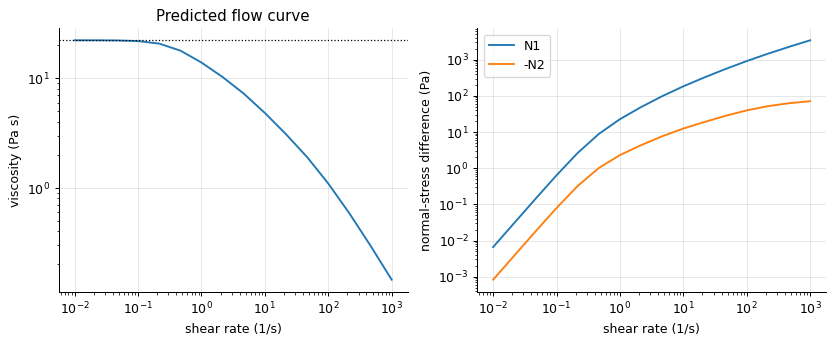

N2/N1 at 10 1/s: -0.059   (negative and small, as measured for polymer solutions)


In [4]:
rates = np.logspace(-2, 3, 16)
st = cm.steady_shear(gie, rates)
eta0 = np.sum(g * tau)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.loglog(rates, st["eta"]); a1.axhline(eta0, color="k", ls=":", lw=1)
a1.set(xlabel="shear rate (1/s)", ylabel="viscosity (Pa s)", title="Predicted flow curve")
a2.loglog(rates, st["N1"], label="N1"); a2.loglog(rates, -st["N2"], label="-N2")
a2.set(xlabel="shear rate (1/s)", ylabel="normal-stress difference (Pa)"); a2.legend(); plt.show()
print(f"N2/N1 at 10 1/s: {st['N2'][10]/st['N1'][10]:.3f}   (negative and small, as measured for polymer solutions)")

The Giesekus model predicts a small negative second normal-stress difference, as observed for polymer
solutions; the UCM model gives $N_2 = 0$. Each nonlinear model has a characteristic signature - Giesekus and
PTT differ most in extension (notebook 14) - so the choice of model should be tested in more than one flow.

## Inside the algorithm: steady Giesekus viscosity in closed form
For a single Giesekus mode the steady shear viscosity has an analytical solution (Bird, Armstrong and
Hassager). Compare it with the long-time limit of the ODE solution:

In [5]:
a_, lam_, eta_ = 0.25, 0.2, 5.0
for Wi in (0.5, 5.0):
    chi = np.sqrt((np.sqrt(1 + 16*a_*(1-a_)*Wi**2) - 1) / (8*a_*(1-a_)*Wi**2))
    f = (1 - chi) / (1 + (1 - 2*a_) * chi)
    exact = eta_ * (1 - f)**2 / (1 + (1 - 2*a_) * f)
    ode = cm.steady_shear([cm.Mode(eta_, lam_, "giesekus", alpha=a_)], [Wi / lam_])["eta"][0]
    print(f"Wi = {Wi}: closed form {exact:.8f} Pa s, ODE {ode:.8f} Pa s")

Wi = 0.5: closed form 4.41101755 Pa s, ODE 4.41101755 Pa s
Wi = 5.0: closed form 1.25816877 Pa s, ODE 1.25816877 Pa s


## Exercises
1. At low shear rates the first normal-stress coefficient $\Psi_1 = N_1/\dot\gamma^2$ tends to $2\sum g_i\tau_i^2$. Check this with the fitted model and with the data at 0.1 1/s.
2. At which strain ($\dot\gamma\,t$) does the stress overshoot occur at 10 and 100 1/s? Is it roughly constant?
3. **Implement it yourself:** integrate the single-mode UCM start-up equations $\lambda\,d\tau_{xy}/dt = -\tau_{xy} + \eta\dot\gamma$, $\lambda\,d\tau_{xx}/dt = -\tau_{xx} + 2\lambda\dot\gamma\tau_{xy}$ with the explicit Euler method and compare with `cm.startup_shear`.